# Binary Classification with PyTorch and sklearn make_circles Dataset

We will demonstrates binary classification using PyTorch on the `make_circles` dataset from `scikit-learn`. We'll cover:
1. Data generation and visualization
2. Neural network architecture design
3. Model training with PyTorch
4. Performance evaluation
5. Decision boundary visualization

## Step 1: Import Required Libraries

We'll use:
- **PyTorch**: For building and training the neural network
- **sklearn**: For generating the make_circles dataset
- **matplotlib**: For visualization
- **numpy**: For numerical operations

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Data
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split # split data into train and test sets
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # evaluate and compare models

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

## Set Random Seed

In [2]:
torch.manual_seed(42)
np.random.seed(42)

## Set Device 
- 'cuda' if available else 'cpu'
- `torch.device` : 'cuda' for GPU and 'cpu' for CPU

In [7]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f'Using device: {device}')
device = torch.device('cpu')

## Step 2: Generate the make_circles Dataset

The `make_circles` dataset creates a binary classification problem where:
- Data points form two concentric circles
- This is a **non-linearly separable** problem
- Perfect for demonstrating the power of neural networks

Parameters:
- `n_samples`: Total number of data points
- `noise`: Standard deviation of Gaussian noise added to data
- `factor`: Scale factor between inner and outer circle

In [3]:
# Generate dataset
n_samples = 1000
X, y = make_circles(n_samples=n_samples, noise=0.1, factor=0.5, random_state=42)

print(f"Dataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Class distribution: Class 0: {np.sum(y==0)}, Class 1: {np.sum(y==1)}")
print(f"\nFeature ranges:")
print(f"X1: [{X[:, 0].min():.3f}, {X[:, 0].max():.3f}]")
print(f"X2: [{X[:, 1].min():.3f}, {X[:, 1].max():.3f}]")

Dataset shape: (1000, 2)
Labels shape: (1000,)
Class distribution: Class 0: 500, Class 1: 500

Feature ranges:
X1: [-1.258, 1.118]
X2: [-1.230, 1.158]


## Step 3: Visualize the Dataset

Let's visualize the concentric circles to understand the problem structure.

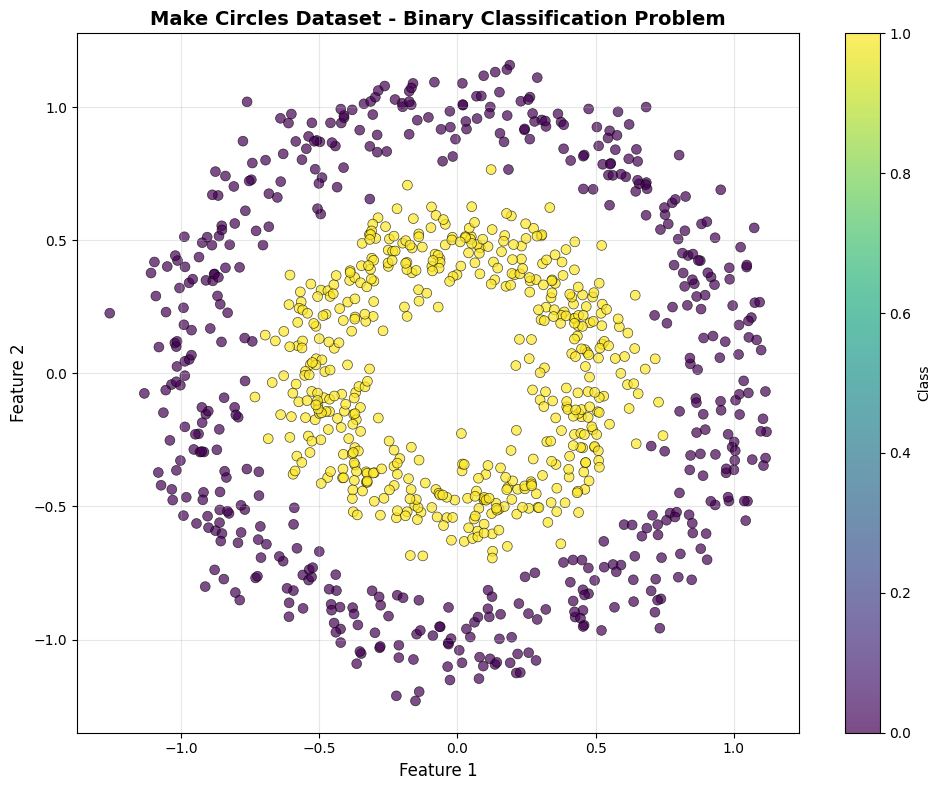


Observation: The data forms two concentric circles.
This is a non-linearly separable problem - no straight line can separate the classes.


In [4]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', 
                     s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Class')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Make Circles Dataset - Binary Classification Problem', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservation: The data forms two concentric circles.")
print("This is a non-linearly separable problem - no straight line can separate the classes.")

## Step 4: Split Data into Training and Testing Sets

We'll use 80% of data for training and 20% for testing.

In [8]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining class distribution: Class 0: {np.sum(y_train==0)}, Class 1: {np.sum(y_train==1)}")
print(f"Testing class distribution: Class 0: {np.sum(y_test==0)}, Class 1: {np.sum(y_test==1)}")

Training set size: 800
Testing set size: 200

Training class distribution: Class 0: 400, Class 1: 400
Testing class distribution: Class 0: 100, Class 1: 100


## Step 5: Convert Data to PyTorch Tensors

PyTorch requires data in `tensor` format for neural network operations.

In [9]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1).to(device)

print(f"Training features tensor shape: {X_train_tensor.shape}")
print(f"Training labels tensor shape: {y_train_tensor.shape}")
print(f"Testing features tensor shape: {X_test_tensor.shape}")
print(f"Testing labels tensor shape: {y_test_tensor.shape}")

Training features tensor shape: torch.Size([800, 2])
Training labels tensor shape: torch.Size([800, 1])
Testing features tensor shape: torch.Size([200, 2])
Testing labels tensor shape: torch.Size([200, 1])


## Step 6: Define the Neural Network Architecture

We'll create a multi-layer perceptron (MLP) with:
- **Input layer**: 2 features (x and y coordinates)
- **Hidden layers**: Multiple layers with ReLU activation to learn non-linear patterns
- **Output layer**: 1 neuron with Sigmoid activation for binary classification

The hidden layers allow the network to learn the circular decision boundary.

In [10]:
class BinaryClassifier(nn.Module):
    def __init__(self, input_size=2, hidden_sizes=[16, 32, 16], output_size=1):
        """
        Binary Classification Neural Network
        
        Args:
            input_size: Number of input features (2 for x, y coordinates)
            hidden_sizes: List of hidden layer sizes
            output_size: Number of output neurons (1 for binary classification)
        """
        super(BinaryClassifier, self).__init__()
        
        # Build layers dynamically
        layers = []
        prev_size = input_size
        
        # Add hidden layers
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1))  # Dropout for regularization
            prev_size = hidden_size
        
        # Add output layer
        layers.append(nn.Linear(prev_size, output_size))
        layers.append(nn.Sigmoid())  # Sigmoid for binary classification
        
        # Create sequential model
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Initialize model
model = BinaryClassifier(input_size=2, hidden_sizes=[16, 32, 16], output_size=1).to(device)

# Print model architecture
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

BinaryClassifier(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=16, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

Total parameters: 1137
Trainable parameters: 1137


## Step 7: Define Loss Function and Optimizer

- **Loss Function**: Binary Cross-Entropy (BCE) - standard for binary classification
- **Optimizer**: Adam - adaptive learning rate optimizer known for good performance

In [11]:
# Loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(f"Loss Function: {criterion}")
print(f"Optimizer: {optimizer}")

Loss Function: BCELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


## Step 8: Train the Model

Training process:
1. **Forward pass**: Compute predictions
2. **Compute loss**: Measure prediction error
3. **Backward pass**: Compute gradients
4. **Update weights**: Adjust parameters using optimizer

We'll track loss and accuracy during training.

In [13]:
# Training parameters
num_epochs = 500
print_every = 10

# Storage for metrics
train_losses = []
train_accuracies = []

# Training loop
for epoch in range(num_epochs):
    # Set model to training mode
    model.train()
    
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Calculate training accuracy
    predictions = (outputs >= 0.5).float()
    accuracy = (predictions == y_train_tensor).float().mean()
    
    # Store metrics
    train_losses.append(loss.item())
    train_accuracies.append(accuracy.item())
    
    # Print progress
    if (epoch + 1) % print_every == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Accuracy: {accuracy.item():.4f}')

print('\nTraining completed!')

Epoch [10/500], Loss: 0.0225, Accuracy: 0.9912
Epoch [20/500], Loss: 0.0173, Accuracy: 0.9975
Epoch [30/500], Loss: 0.0157, Accuracy: 0.9912
Epoch [40/500], Loss: 0.0187, Accuracy: 0.9937
Epoch [50/500], Loss: 0.0123, Accuracy: 0.9962
Epoch [60/500], Loss: 0.0121, Accuracy: 0.9962
Epoch [70/500], Loss: 0.0235, Accuracy: 0.9887
Epoch [80/500], Loss: 0.0148, Accuracy: 0.9937
Epoch [90/500], Loss: 0.0316, Accuracy: 0.9875
Epoch [100/500], Loss: 0.0351, Accuracy: 0.9912
Epoch [110/500], Loss: 0.0204, Accuracy: 0.9950
Epoch [120/500], Loss: 0.0261, Accuracy: 0.9912
Epoch [130/500], Loss: 0.0137, Accuracy: 0.9937
Epoch [140/500], Loss: 0.0206, Accuracy: 0.9937
Epoch [150/500], Loss: 0.0177, Accuracy: 0.9950
Epoch [160/500], Loss: 0.0238, Accuracy: 0.9937
Epoch [170/500], Loss: 0.0162, Accuracy: 0.9937
Epoch [180/500], Loss: 0.0162, Accuracy: 0.9937
Epoch [190/500], Loss: 0.0084, Accuracy: 0.9987
Epoch [200/500], Loss: 0.0152, Accuracy: 0.9962
Epoch [210/500], Loss: 0.0115, Accuracy: 0.9950
E

## Step 9: Visualize Training Progress

Plot the loss and accuracy curves to see how the model learned over time.

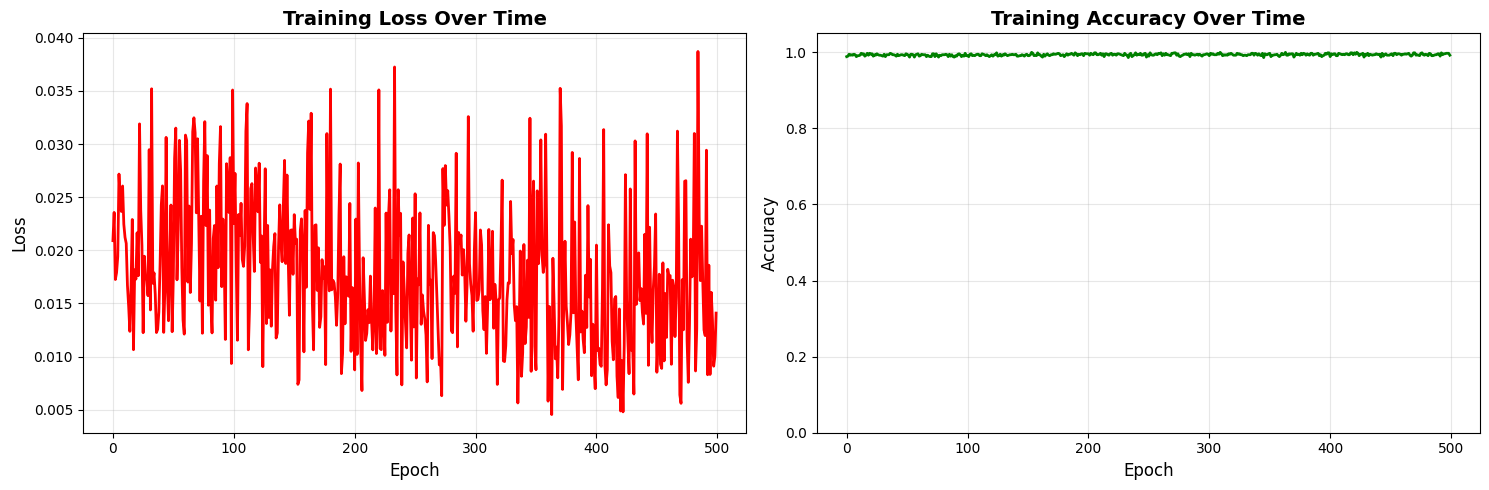

Final Training Loss: 0.0141
Final Training Accuracy: 0.9925


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot training loss
ax1.plot(train_losses, linewidth=2, color='red')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot training accuracy
ax2.plot(train_accuracies, linewidth=2, color='green')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training Accuracy Over Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Training Accuracy: {train_accuracies[-1]:.4f}")

## Step 10: Evaluate Model on Test Set

Evaluate the model on unseen test data to check for overfitting and generalization.

In [15]:
# Set model to evaluation mode
model.eval()

# Make predictions on test set
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_predictions = (test_outputs >= 0.5).float()
    test_loss = criterion(test_outputs, y_test_tensor)
    test_accuracy = (test_predictions == y_test_tensor).float().mean()

# Convert to numpy for sklearn metrics
y_pred = test_predictions.cpu().numpy().flatten()
y_true = y_test_tensor.cpu().numpy().flatten()

print("\n" + "="*50)
print("MODEL EVALUATION RESULTS")
print("="*50)
print(f"\nTest Loss: {test_loss.item():.4f}")
print(f"Test Accuracy: {test_accuracy.item():.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1']))


MODEL EVALUATION RESULTS

Test Loss: 0.0433
Test Accuracy: 0.9900

Classification Report:

              precision    recall  f1-score   support

     Class 0       1.00      0.98      0.99       100
     Class 1       0.98      1.00      0.99       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



## Step 11: Confusion Matrix Visualization

The confusion matrix shows the distribution of correct and incorrect predictions.

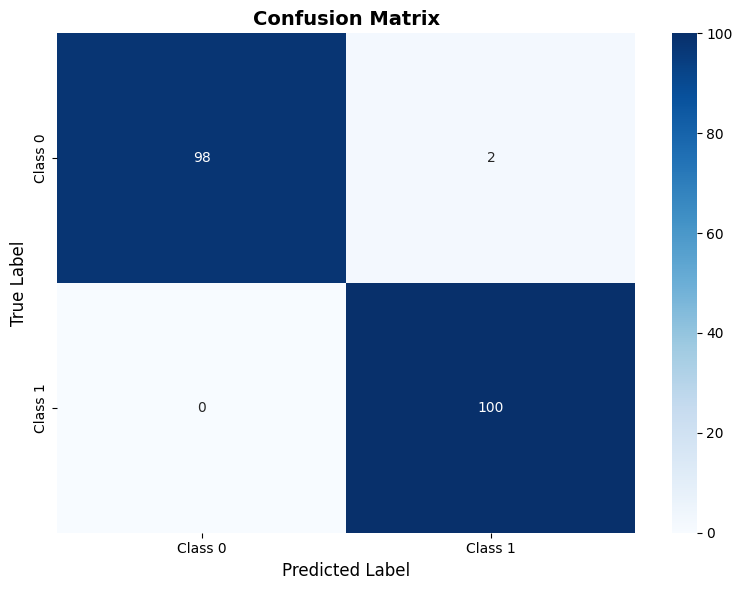


Confusion Matrix Breakdown:
True Negatives (TN): 98
False Positives (FP): 2
False Negatives (FN): 0
True Positives (TP): 100

Precision: 0.9804
Recall: 1.0000


In [16]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print(f"\nPrecision: {tp/(tp+fp):.4f}")
print(f"Recall: {tp/(tp+fn):.4f}")

## Step 12: Visualize Decision Boundary

This is the most important visualization! It shows how the neural network learned to separate the two circles.

The decision boundary is the region where the model switches from predicting one class to another.

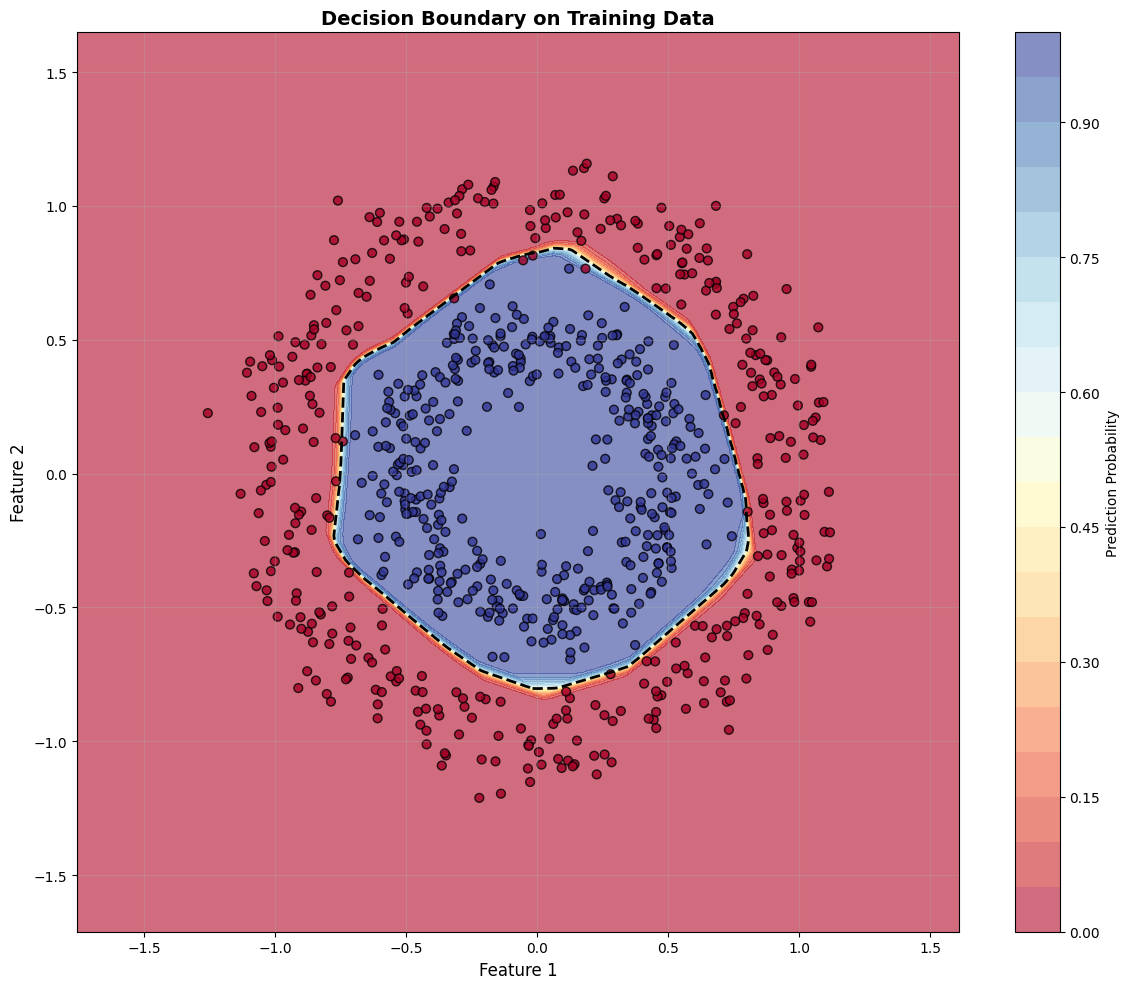

In [17]:
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """
    Plot the decision boundary of the model
    
    Args:
        model: Trained PyTorch model
        X: Feature data (numpy array)
        y: Labels (numpy array)
        title: Plot title
    """
    # Set model to evaluation mode
    model.eval()
    
    # Create a mesh grid
    h = 0.01  # Step size in the mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Make predictions for each point in the mesh
    mesh_data = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    
    with torch.no_grad():
        Z = model(mesh_data)
        Z = Z.cpu().numpy()
    
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary and data points
    plt.figure(figsize=(12, 10))
    
    # Plot decision boundary (contour plot)
    plt.contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(label='Prediction Probability')
    
    # Plot decision threshold (0.5)
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    
    # Plot data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', 
                         s=40, edgecolors='black', linewidth=1, alpha=0.8)
    
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot decision boundary on training data
plot_decision_boundary(model, X_train, y_train, 
                      title="Decision Boundary on Training Data")

## Step 13: Decision Boundary on Test Data

Let's verify the decision boundary on test data to ensure the model generalizes well.

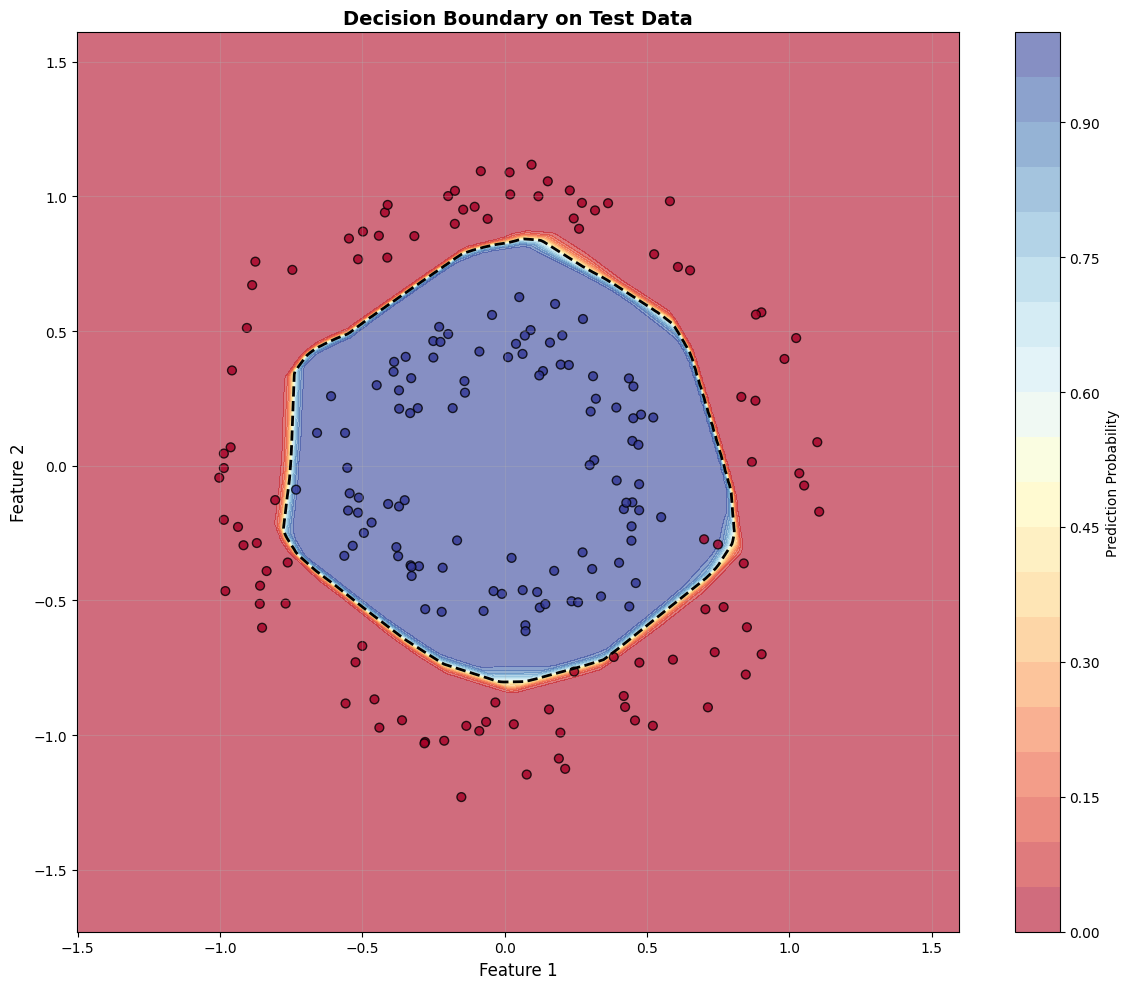

In [18]:
# Plot decision boundary on test data
plot_decision_boundary(model, X_test, y_test, 
                      title="Decision Boundary on Test Data")

## Step 14: Compare Training vs Test Performance

Side-by-side comparison of decision boundaries on training and test sets.

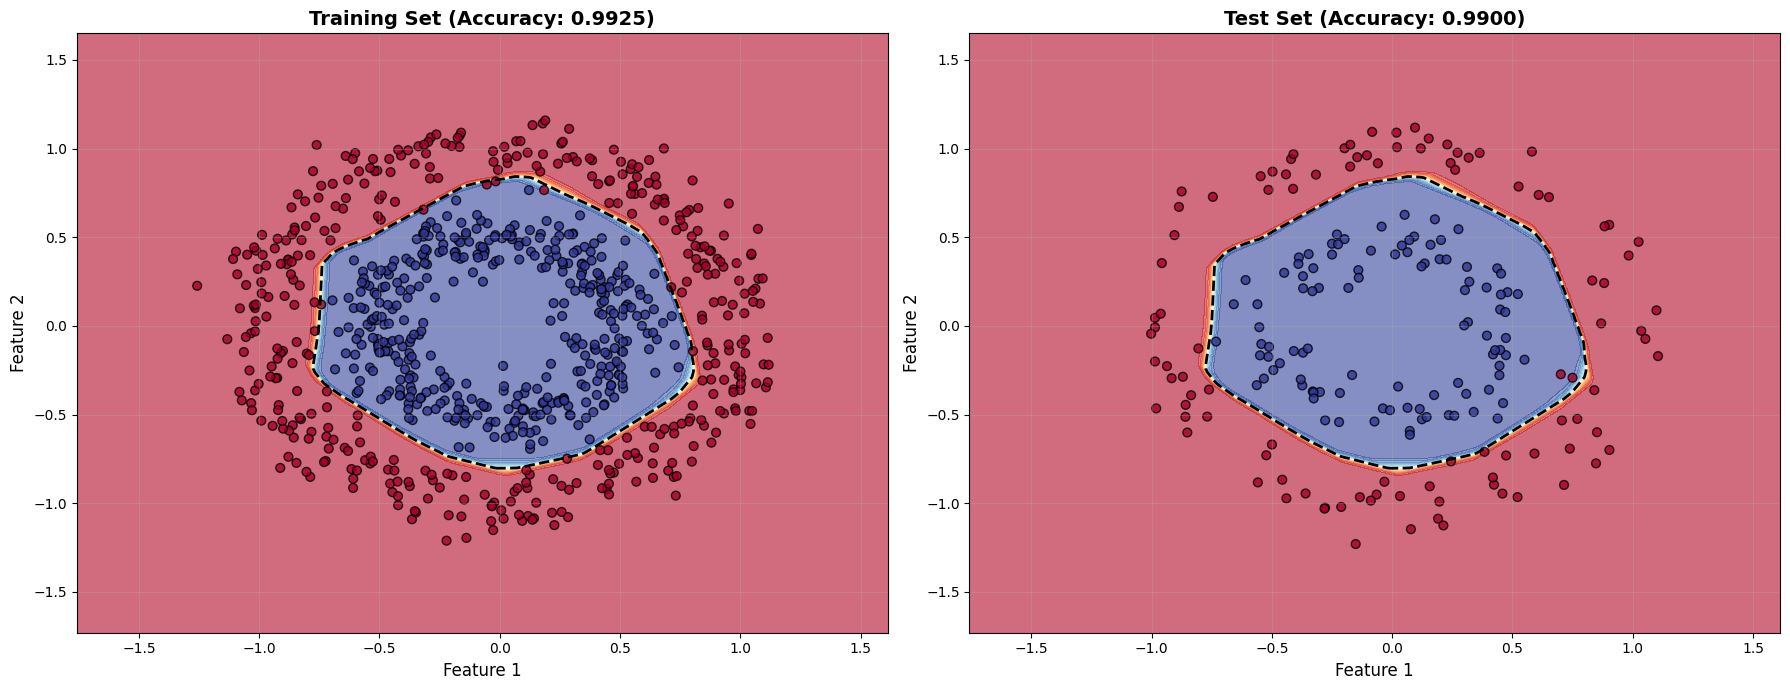


Key Observations:
1. The model successfully learned a non-linear decision boundary
2. The boundary successfully separates the two concentric circles
3. Similar performance on training and test sets indicates good generalization
4. The dashed black line shows the decision threshold (probability = 0.5)


In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Create mesh for both plots
h = 0.01
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

mesh_data = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
model.eval()
with torch.no_grad():
    Z = model(mesh_data).cpu().numpy()
Z = Z.reshape(xx.shape)

# Plot 1: Training data
ax1.contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.6)
ax1.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu', 
           s=40, edgecolors='black', linewidth=1, alpha=0.8)
ax1.set_xlabel('Feature 1', fontsize=12)
ax1.set_ylabel('Feature 2', fontsize=12)
ax1.set_title(f'Training Set (Accuracy: {train_accuracies[-1]:.4f})', 
             fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot 2: Test data
ax2.contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.6)
ax2.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
scatter = ax2.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlBu', 
                     s=40, edgecolors='black', linewidth=1, alpha=0.8)
ax2.set_xlabel('Feature 1', fontsize=12)
ax2.set_ylabel('Feature 2', fontsize=12)
ax2.set_title(f'Test Set (Accuracy: {test_accuracy.item():.4f})', 
             fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("1. The model successfully learned a non-linear decision boundary")
print("2. The boundary successfully separates the two concentric circles")
print("3. Similar performance on training and test sets indicates good generalization")
print("4. The dashed black line shows the decision threshold (probability = 0.5)")

## Step 15: Summary and Key Takeaways

### What We Accomplished:

1. **Generated non-linearly separable data** using sklearn's make_circles
2. **Built a neural network** with PyTorch capable of learning non-linear patterns
3. **Trained the model** using backpropagation and Adam optimizer
4. **Evaluated performance** on both training and test sets
5. **Visualized the decision boundary** to understand model behavior

### Key Insights:

- **Non-linear problems require non-linear solutions**: Linear classifiers (like logistic regression) would fail on this problem
- **Hidden layers with activation functions** enable the network to learn complex patterns
- **The decision boundary visualization** provides intuition about what the model learned
- **Good generalization**: Similar accuracy on training and test sets indicates the model didn't overfit

### Model Architecture Summary:
- Input: 2 features
- Hidden layers: [16, 32, 16] neurons with ReLU activation
- Output: 1 neuron with Sigmoid activation
- Loss: Binary Cross-Entropy
- Optimizer: Adam with learning rate 0.01

### Performance Metrics:

In [ ]:
print("\n" + "="*60)
print("FINAL PERFORMANCE SUMMARY")
print("="*60)
print(f"\nTraining Accuracy: {train_accuracies[-1]:.4f} ({train_accuracies[-1]*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy.item():.4f} ({test_accuracy.item()*100:.2f}%)")
print(f"\nTraining Loss: {train_losses[-1]:.4f}")
print(f"Test Loss: {test_loss.item():.4f}")
print(f"\nGeneralization Gap: {abs(train_accuracies[-1] - test_accuracy.item()):.4f}")
print("\n" + "="*60)

if abs(train_accuracies[-1] - test_accuracy.item()) < 0.05:
    print("Model generalizes well (< 5% accuracy gap)")
else:
    print("Model may be overfitting (> 5% accuracy gap)")
print("="*60)

## Step 16: Make Predictions on New Data

Let's demonstrate how to use the trained model to make predictions on new, unseen data points.

In [ ]:
# Create some example points
new_points = np.array([
    [0.0, 0.0],    # Center point
    [0.5, 0.0],    # Inner circle
    [1.0, 0.0],    # Outer circle
    [0.0, 0.5],    # Inner circle
    [0.0, 1.0],    # Outer circle
])

# Convert to tensor
new_points_tensor = torch.FloatTensor(new_points).to(device)

# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(new_points_tensor)
    predicted_classes = (predictions >= 0.5).float()

# Display results
print("\nPredictions on New Points:")
print("="*70)
print(f"{'Point':<20} {'Probability':<20} {'Predicted Class':<20}")
print("="*70)

for i, (point, prob, pred_class) in enumerate(zip(new_points, predictions.cpu().numpy(), predicted_classes.cpu().numpy())):
    print(f"[{point[0]:6.2f}, {point[1]:6.2f}]      {prob[0]:6.4f}              {int(pred_class[0])}")

print("="*70)

## Conclusion

WE have demonstrated a complete workflow for binary classification using PyTorch:

1. Data generation and exploration
2. Neural network design for non-linear problems
3. Model training with proper loss and optimization
4. Performance evaluation with multiple metrics
5. Visual analysis of decision boundaries
6. Making predictions on new data

The neural network successfully learned to classify the concentric circles, demonstrating its ability to solve non-linearly separable problems that simpler models cannot handle.